In [1]:
import os
import sys
import argparse
import wandb

# Ensure repository root is on sys.path so "Code" is importable
REPO_ROOT = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from Code.src.utils.io import read_json_file, save_json_file
from Code.src.utils.evaluation_utils import overall_score_on_whole_data
from Code.src.utils.evaluation_utils import (
    doing_exact_match,
    calculating_semantic_score,
    relaxed_match_thresholding,
    doing_complex_matching,
    getting_complex_match_pairs,
    overall_score_on_whole_data,
)

/dartfs-hpc/rc/home/j/f006f3j/lab/omar/conda/loqaGpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Saving the shallow QG files

In [2]:
output_path = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/"

eval_dict = {}
dataset_names = ["DiscourseEE"]# "CaseReportBench", "PHEE", "DiscourseEE", "MACCROBAT"
split_name = "gold-test"
qo_model_name = "gpt-oss-120b"

for dataset_name in dataset_names:
    file_name = f"optimized_loqa-{dataset_name}-{split_name}-{qo_model_name}-zs-v0.json"
    file_path = os.path.join(output_path, dataset_name, file_name)
    if os.path.exists(file_path):
        print(f"File exists: {file_path}")
    else:
        print(f"File does not exist: {file_path}")

    predictions = read_json_file(file_path)
    eval_dict[dataset_name] = predictions

File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/DiscourseEE/optimized_loqa-DiscourseEE-gold-test-gpt-oss-120b-zs-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/DiscourseEE/optimized_loqa-DiscourseEE-gold-test-gpt-oss-120b-zs-v0.json


In [3]:
import os

# Fields to remove if present
FIELDS_TO_REMOVE = [
    "trace_history",
    "processed_gt_args",
    "best_trace",
    "optimized_loqa_args",
    "best_iteration_number",
    "best_score",
    "total_iterations",
]

# Where to save cleaned files
clean_output_root = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/"

os.makedirs(clean_output_root, exist_ok=True)

for dataset_name in dataset_names:
    # Get original predictions from eval_dict (already loaded above)
    preds = eval_dict[dataset_name]

    cleaned_preds = []
    for ex in preds:
        # Make a shallow copy and remove unwanted fields if they exist
        ex_clean = {k: v for k, v in ex.items() if k not in FIELDS_TO_REMOVE}
        cleaned_preds.append(ex_clean)

    # Build input and output file names
    file_name = f"optimized_loqa-qg-{dataset_name}-{split_name}-{qo_model_name}-zs-v0.json"

    out_dir = os.path.join(clean_output_root, dataset_name)
    os.makedirs(out_dir, exist_ok=True)
    out_file_path = os.path.join(out_dir, file_name)
    print(len(cleaned_preds))
    print(f"Saving cleaned file for {dataset_name} to: {out_file_path}")
    save_json_file(cleaned_preds, out_file_path)

500
Saving cleaned file for DiscourseEE to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/DiscourseEE/optimized_loqa-qg-DiscourseEE-gold-test-gpt-oss-120b-zs-v0.json
Data saved to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/DiscourseEE/optimized_loqa-qg-DiscourseEE-gold-test-gpt-oss-120b-zs-v0.json


## Getting the exact, relaxed and complex match results on the datasets

In [10]:
# it takes long time to evaluate
output_path = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/"

eval_dict = {}
dataset_names = ["PHEE"]
for dataset_name in dataset_names:
    file_name = f"optimized_loqa-{dataset_name}-gold-test-gpt-oss-120b-zs-v0.json"
    file_path = os.path.join(output_path, dataset_name, file_name)
    if os.path.exists(file_path):
        print(f"File exists: {file_path}")
    else:
        print(f"File does not exist: {file_path}")

    predictions = read_json_file(file_path)
    eval_data = []
    matched_pred_cnt, matched_gt_cnt, pd_cnt, gt_cnt = 0, 0, 0, 0
    n_skipped = 0
    for pred in predictions:
        if pred.get("best_trace") is None:
            n_skipped += 1
            print("No best trace for sample: ", pred.get("serial-number"))
            continue
        scores = pred.get("best_trace").get("scores")

        matched_pred_cnt += scores.get("n_matched_pred")
        matched_gt_cnt += scores.get("n_matched_gt")
        pd_cnt += scores.get("n_pred")
        gt_cnt += scores.get("n_gt")

    n_evaluated = len(predictions) - n_skipped
    print("="*60)
    print(f"Dataset: {dataset_name}")
    print(f"Total samples: {len(predictions)} (evaluated: {n_evaluated}, skipped: {n_skipped})")
    print("(gt_cnt/pd_cnt below are sums over evaluated samples only, not full dataset)")
    print(f"Total matched predictions: {matched_pred_cnt}")
    print(f"Total matched ground truth: {matched_gt_cnt}")
    print(f"Total predictions: {pd_cnt}")
    print(f"Total ground truth: {gt_cnt}")

    precision_raw = matched_pred_cnt / pd_cnt
    recall_raw = matched_gt_cnt / gt_cnt
    f1_raw = (2 * precision_raw * recall_raw) / (precision_raw + recall_raw)

    precision = round(precision_raw * 100, 2)
    recall = round(recall_raw * 100, 2)
    f1 = round(f1_raw * 100, 2)

    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1: ", f1)
    print("ground truth: ", gt_cnt)
    print("predictions: ", pd_cnt)


File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/PHEE/optimized_loqa-PHEE-gold-test-gpt-oss-120b-zs-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/PHEE/optimized_loqa-PHEE-gold-test-gpt-oss-120b-zs-v0.json
No best trace for sample:  test-8957
No best trace for sample:  test-4862
No best trace for sample:  test-12093
No best trace for sample:  test-13655
No best trace for sample:  test-437
No best trace for sample:  test-11540
No best trace for sample:  test-10743
No best trace for sample:  test-6136
No best trace for sample:  test-8763
No best trace for sample:  test-11641
No best trace for sample:  test-7771
No best trace for sample:  test-12468
No best trace for sample:  test-13051
No best trace for sample:  test-11283
No best trace for sample:  test-11101
Dataset: PHEE
Total samples: 500 (evaluated: 485, skipped: 15)
(gt_cnt/pd_cnt below are sums over evaluated samples only, not full dataset)
Total matched predictions: 584
T

## Loading data

In [13]:
## Loading the LoQA outputs
output_path = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/"

eval_dict = {}
dataset_names = ["CaseReportBench", "PHEE", "DiscourseEE", "MACCROBAT"]
for dataset_name in dataset_names:
    file_name = f"optimized_loqa-{dataset_name}-gold-test-gpt-oss-120b-v0.json"
    file_path = os.path.join(output_path, dataset_name, file_name)
    if os.path.exists(file_path):
        print(f"File exists: {file_path}")
    else:
        print(f"File does not exist: {file_path}")

    predictions = read_json_file(file_path)
    eval_dict[dataset_name] = predictions

File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/CaseReportBench/optimized_loqa-CaseReportBench-gold-test-gpt-oss-120b-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/CaseReportBench/optimized_loqa-CaseReportBench-gold-test-gpt-oss-120b-v0.json
File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/PHEE/optimized_loqa-PHEE-gold-test-gpt-oss-120b-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/PHEE/optimized_loqa-PHEE-gold-test-gpt-oss-120b-v0.json
File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/DiscourseEE/optimized_loqa-DiscourseEE-gold-test-gpt-oss-120b-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/DiscourseEE/optimized_loqa-DiscourseEE-gold-test-gpt-oss-120b-v0.json
File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/MACCROBAT/optimized_loqa-MACCROBAT-gold-test-gpt-oss-120b-v0.json
Reading JSON file

## Checking best iteration

In [14]:
dataset_names = list(eval_dict.keys())
for dataset_name in dataset_names:
    print(dataset_name)
    print(len(eval_dict[dataset_name]))
    print(eval_dict[dataset_name][0])
    eval_data = eval_dict[dataset_name]
    for pred in eval_data:
        print(pred['best_iteration_number'])
        break

CaseReportBench
500
{'serial-number': 'test-499', 'pmcid': '5554421', 'text': "{'2. Case Presentation': 'A 19-year-old female was presented with palmoplantar hyperkeratosis from the age of 4 years and complete loss of teeth by the age of 14 which was the characteristic criteria for PLS. She was the second child born to apparently healthy consanguineous parents (cousins). Her older brother also suffered from PLS but two younger siblings were normal. Previous medical history showed that her permanent and deciduous teeth were lost after erupting normally. On physical examination, there was diffuse palmoplantar keratoderma ( Figure 1 ). Intraoral examination revealed complete edentulous ridges with normal overlying mucosa. In the panoramic view, severe maxillary and mandibular bone resorption along with bilateral pneumatization of maxillary sinuses were seen. Her chin was small but the other systemic examinations, routine laboratory examinations, chest X-ray, and skull X-ray were normal. S

In [15]:
from collections import Counter

# Create buckets for each dataset showing count of items by best_iteration_number
iteration_buckets = {}

for dataset_name in dataset_names:
    eval_data = eval_dict[dataset_name]
    
    # Count how many items have each best_iteration_number
    iteration_counts = Counter()
    for pred in eval_data:
        iter_num = pred.get('best_iteration_number', 0)
        iteration_counts[iter_num] += 1
    
    iteration_buckets[dataset_name] = dict(sorted(iteration_counts.items()))
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"Total items: {len(eval_data)}")
    print(f"\nBest Iteration Number Distribution:")
    for iter_num in sorted(iteration_counts.keys()):
        count = iteration_counts[iter_num]
        percentage = (count / len(eval_data)) * 100
        print(f"  Iteration {iter_num}: {count:5d} items ({percentage:5.2f}%)")
    print()

# Store buckets for later use
print("\nBuckets dictionary:")
print(iteration_buckets)


Dataset: CaseReportBench
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   281 items (56.20%)
  Iteration 1:   104 items (20.80%)
  Iteration 2:    51 items (10.20%)
  Iteration 3:    57 items (11.40%)
  Iteration 4:     7 items ( 1.40%)


Dataset: PHEE
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   371 items (74.20%)
  Iteration 1:    84 items (16.80%)
  Iteration 2:    32 items ( 6.40%)
  Iteration 3:    11 items ( 2.20%)
  Iteration 4:     2 items ( 0.40%)


Dataset: DiscourseEE
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   246 items (49.20%)
  Iteration 1:   127 items (25.40%)
  Iteration 2:    81 items (16.20%)
  Iteration 3:    31 items ( 6.20%)
  Iteration 4:    15 items ( 3.00%)


Dataset: MACCROBAT
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   335 items (67.00%)
  Iteration 1:   120 items (24.00%)
  Iteration 2:    36 items ( 7.20%)
  Iteration 3:     6 items ( 1.20%)
  Iteration 4:

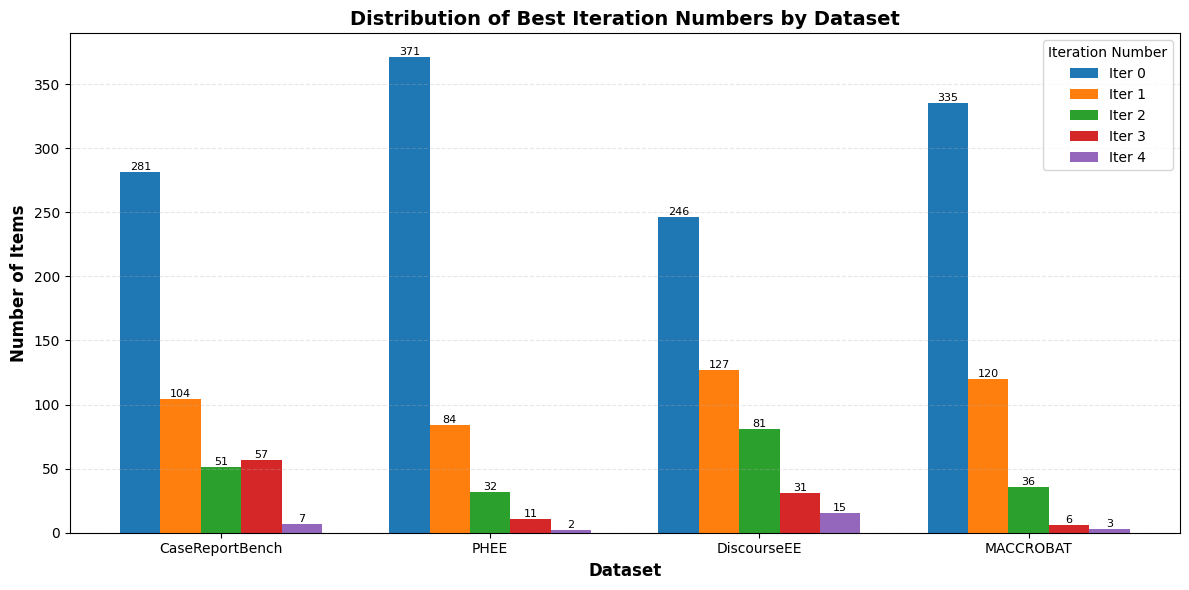

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
datasets = list(iteration_buckets.keys())
max_iter = max(max(buckets.keys()) for buckets in iteration_buckets.values()) + 1
iteration_numbers = list(range(max_iter))

# Create arrays for each iteration number (grouped by dataset)
data_matrix = []
for iter_num in iteration_numbers:
    row = [iteration_buckets[dataset].get(iter_num, 0) for dataset in datasets]
    data_matrix.append(row)

# Create the barplot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(datasets))
width = 0.15  # Width of bars (adjusted for 5 iteration numbers)

# Create bars for each iteration number
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Different colors for each iteration
for i, iter_num in enumerate(iteration_numbers):
    bars = ax.bar(x + i * width, data_matrix[i], width, label=f'Iter {iter_num}', color=colors[i % len(colors)])
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Items', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Best Iteration Numbers by Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(iteration_numbers) - 1) / 2)
ax.set_xticklabels(datasets)
ax.legend(fontsize=10, title='Iteration Number')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Distribution of Best questions

In [17]:
# How many questions in the final best? Bucket: samples with 1, 2, 3, ... questions
from collections import Counter

question_count_buckets = {}
for dataset_name in dataset_names:
    eval_data = eval_dict[dataset_name]
    counts = Counter()
    for pred in eval_data:
        # Use best_trace['loqa_questions'] or fallback to optimized_loqa_questions
        bt = pred.get('best_trace')
        qs = (bt.get('loqa_questions') if bt else None) or pred.get('optimized_loqa_questions') or []
        n = len(qs) if isinstance(qs, list) else 0
        n_bucket = min(n, 5)  # 10+ in one bucket
        counts[n_bucket] += 1
    question_count_buckets[dataset_name] = dict(sorted(counts.items()))
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"Total samples: {len(eval_data)}")
    print(f"\nBuckets (number of questions per sample):")
    for n_q in sorted(counts.keys()):
        cnt = counts[n_q]
        pct = (cnt / len(eval_data)) * 100
        label = f"{n_q}+" if n_q == 5 else str(n_q)
        print(f"  {label} question(s): {cnt:5d} samples ({pct:5.2f}%)")
print("\nBuckets dictionary:")
print(question_count_buckets)


Dataset: CaseReportBench
Total samples: 500

Buckets (number of questions per sample):
  1 question(s):   225 samples (45.00%)
  2 question(s):    96 samples (19.20%)
  3 question(s):    49 samples ( 9.80%)
  4 question(s):    36 samples ( 7.20%)
  5+ question(s):    94 samples (18.80%)

Dataset: PHEE
Total samples: 500

Buckets (number of questions per sample):
  1 question(s):   405 samples (81.00%)
  2 question(s):    67 samples (13.40%)
  3 question(s):    22 samples ( 4.40%)
  4 question(s):     3 samples ( 0.60%)
  5+ question(s):     3 samples ( 0.60%)

Dataset: DiscourseEE
Total samples: 500

Buckets (number of questions per sample):
  0 question(s):     2 samples ( 0.40%)
  1 question(s):   354 samples (70.80%)
  2 question(s):    90 samples (18.00%)
  3 question(s):    34 samples ( 6.80%)
  4 question(s):    12 samples ( 2.40%)
  5+ question(s):     8 samples ( 1.60%)

Dataset: MACCROBAT
Total samples: 500

Buckets (number of questions per sample):
  1 question(s):   429 sam

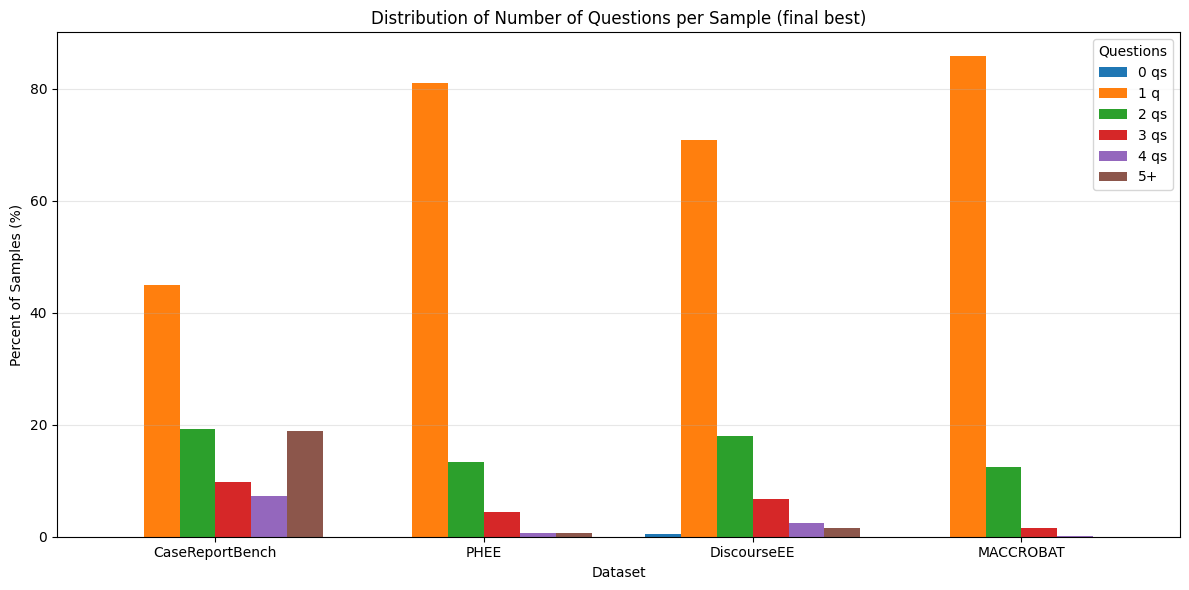

In [18]:
# Bar chart: question count buckets by dataset (10+ in one bucket) -- PERCENTAGES
nq_range = sorted(set(k for b in question_count_buckets.values() for k in b.keys()))
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(dataset_names))
width = max(0.08, 0.8 / max(len(nq_range), 1))

# totals per dataset
_totals = {ds: sum(question_count_buckets[ds].values()) for ds in dataset_names}

for i, nq in enumerate(nq_range):
    pct_vals = [
        (question_count_buckets[ds].get(nq, 0) / _totals[ds] * 100.0) if _totals[ds] else 0.0
        for ds in dataset_names
    ]
    lbl = f'{nq}+' if nq == 5 else (f'{nq} q' if nq == 1 else f'{nq} qs')
    ax.bar(x + i * width, pct_vals, width, label=lbl)

ax.set_xlabel('Dataset')
ax.set_ylabel('Percent of Samples (%)')
ax.set_title('Distribution of Number of Questions per Sample (final best)')
ax.set_xticks(x + width * (len(nq_range) - 1) / 2)
ax.set_xticklabels(dataset_names)
ax.legend(title='Questions')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Matched argument characteristics by best_iteration_number

Hypothesis: Arguments that are more complex (longer, more words, contain numbers) need more refinement iterations to match.  
We extract features from `best_trace['all_matched_pairs']` (using ground truth) and group by `best_iteration_number`.

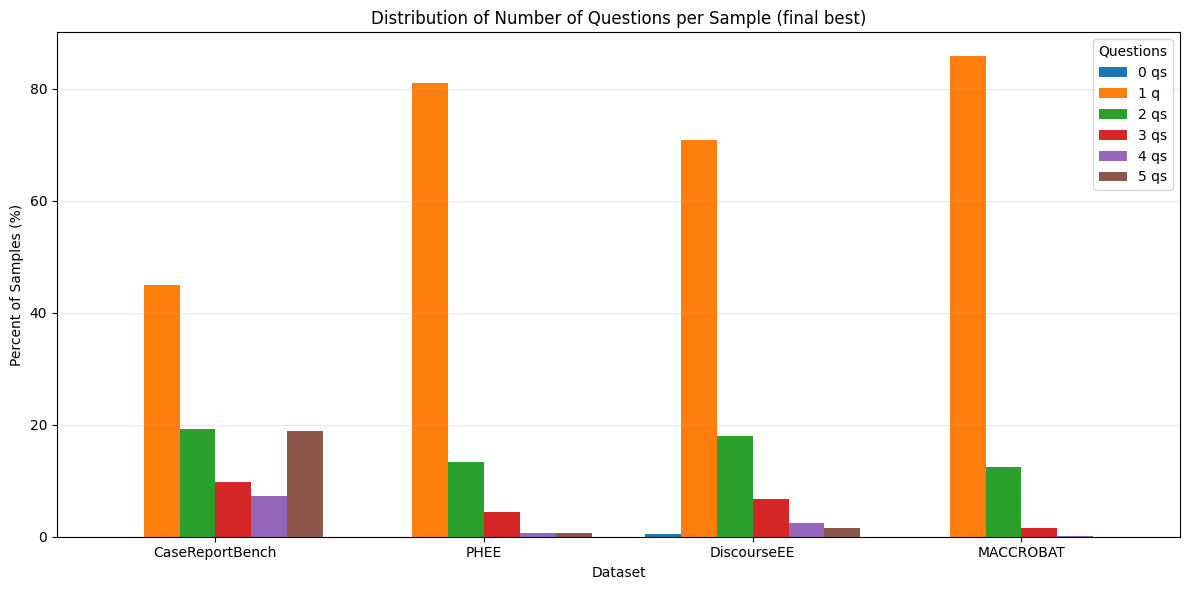

In [19]:
# Percentage version of the buckets plot (each dataset sums to 100%)

nq_range = sorted(set(k for b in question_count_buckets.values() for k in b.keys()))
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(dataset_names))
width = max(0.08, 0.8 / max(len(nq_range), 1))

_totals = {ds: sum(question_count_buckets[ds].values()) for ds in dataset_names}

for i, nq in enumerate(nq_range):
    pct_vals = [
        (question_count_buckets[ds].get(nq, 0) / _totals[ds] * 100.0) if _totals[ds] else 0.0
        for ds in dataset_names
    ]
    lbl = f'{nq}+' if nq == 10 else (f'{nq} q' if nq == 1 else f'{nq} qs')
    ax.bar(x + i * width, pct_vals, width, label=lbl)

ax.set_xlabel('Dataset')
ax.set_ylabel('Percent of Samples (%)')
ax.set_title('Distribution of Number of Questions per Sample (final best)')
ax.set_xticks(x + width * (len(nq_range) - 1) / 2)
ax.set_xticklabels(dataset_names)
ax.legend(title='Questions')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
## Characteristic analysis: matched arguments by best_iteration_number

# Hypothesis: More complex arguments need more iterations
# Use ground truth (gt) from all_matched_pairs for consistency

import re

def arg_features(text):
    """Extract complexity features from an argument string."""
    words = text.split()
    has_numbers = bool(re.search(r'\d', text))
    return {
        'char_len': len(text),
        'word_count': len(words),
        'has_numbers': has_numbers,
    }

# Collect all matched arguments grouped by (dataset, best_iteration_number)
# each row: dataset, best_iter, char_len, word_count, has_numbers, is_exact_match
rows = []
for dataset_name in dataset_names:
    for pred in eval_dict[dataset_name]:
        best_iter = pred.get('best_iteration_number', 0)
        bt = pred.get('best_trace')
        if bt is None:
            continue
        em_set = set(tuple(p) for p in (bt.get('em_pairs') or []))
        for pair in bt.get('all_matched_pairs') or []:
            pred_arg, gt_arg = pair[0], pair[1]
            feats = arg_features(gt_arg)
            feats['is_exact_match'] = tuple(pair) in em_set
            feats['dataset'] = dataset_name
            feats['best_iteration'] = best_iter
            rows.append(feats)

import pandas as pd
df = pd.DataFrame(rows)

In [21]:
# Per-dataset breakdown
print("Mean word count by dataset and best_iteration:")
pt = df.pivot_table(values='word_count', index='best_iteration', columns='dataset', aggfunc='mean')
print(pt.round(2))
print("\nMean char length by dataset and best_iteration:")
pt2 = df.pivot_table(values='char_len', index='best_iteration', columns='dataset', aggfunc='mean')
print(pt2.round(2))

Mean word count by dataset and best_iteration:
dataset         CaseReportBench  DiscourseEE  MACCROBAT   PHEE
best_iteration                                                
0                         15.28         2.84       1.83   1.95
1                         20.75         3.27       1.50   3.98
2                         26.77         3.87       1.48   4.36
3                         26.54         3.28       1.43   3.38
4                         18.15         3.76       1.00  10.50

Mean char length by dataset and best_iteration:
dataset         CaseReportBench  DiscourseEE  MACCROBAT   PHEE
best_iteration                                                
0                         96.91        16.02      11.37  15.77
1                        129.32        19.95      10.48  31.54
2                        166.73        23.83      10.41  31.97
3                        167.51        20.00      10.43  26.38
4                        117.04        24.59       8.67  74.50


## Analysis leakage is minimal or not happening. 

In [22]:
# Randomly select up to 100 best traces per dataset
# Conditions: best_iteration_number > 0 AND best_trace.scores['f1'] == 1.0

import random

random.seed(0)  # for reproducibility

selected_best_traces = {}

for dataset_name in dataset_names:
    eval_data = eval_dict[dataset_name]
    candidates = []
    for item in eval_data:
        best_iter = item.get('best_iteration_number', 0)
        bt = item.get('best_trace')
        trace_history = item.get('trace_history')
        if best_iter is None or bt is None:
            continue
        if best_iter <= 0:
            continue
        scores = (bt.get('scores') or {})
        if scores.get('f1') != 1.0:
            continue
        candidates.append({
            'serial-number': item.get('serial-number'),
            'role': item.get('role'),
            'ground_truth_args': item.get('processed_gt_args') or [],
            'trace_history': trace_history
        })

    if not candidates:
        print(f"No matching items for dataset {dataset_name}.")
        selected_best_traces[dataset_name] = []
        continue

    k = min(50, len(candidates))
    selected = random.sample(candidates, k)
    selected_best_traces[dataset_name] = selected
    print(f"Dataset: {dataset_name} — selected {k} / {len(candidates)} candidates")

# 'selected_best_traces' now holds the random samples per dataset

Dataset: CaseReportBench — selected 50 / 168 candidates
Dataset: PHEE — selected 50 / 123 candidates
Dataset: DiscourseEE — selected 50 / 210 candidates
Dataset: MACCROBAT — selected 50 / 163 candidates


In [23]:
import json

output_dir = os.path.join("/dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs", "analysis")
os.makedirs(output_dir, exist_ok=True)

for dataset_name in dataset_names:
    data = selected_best_traces.get(dataset_name, [])
    file_path = os.path.join(output_dir, f"{dataset_name}_qo_selected_trace_history.json")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Saved {len(data)} items for dataset '{dataset_name}' to {file_path}")



Saved 50 items for dataset 'CaseReportBench' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/CaseReportBench_qo_selected_trace_history.json
Saved 50 items for dataset 'PHEE' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/PHEE_qo_selected_trace_history.json
Saved 50 items for dataset 'DiscourseEE' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/DiscourseEE_qo_selected_trace_history.json
Saved 50 items for dataset 'MACCROBAT' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/MACCROBAT_qo_selected_trace_history.json


## Checking how many samples receive score=0.0 and their trajectory


In [24]:
# Randomly select up to 50 traces per dataset where f1 == 0.0
# Conditions: best_iteration_number > 0 AND best_trace.scores['f1'] == 1.0

import random

random.seed(0)  # for reproducibility

selected_traces = {}

for dataset_name in dataset_names:
    eval_data = eval_dict[dataset_name]
    candidates = []
    print(len(eval_data))
    for item in eval_data:
        best_iter = item.get('best_iteration_number', 0)
        bt = item.get('best_trace')
        trace_history = item.get('trace_history')
        if best_iter is None or bt is None: # according to my code when bt is None, f1 is 0.0
            candidates.append({
                'serial-number': item.get('serial-number'),
                'role': item.get('role'),
                'ground_truth_args': item.get('processed_gt_args') or [],
                'trace_history': trace_history
            })
    if not candidates:
        print(f"No matching items for dataset {dataset_name}.")
        selected_traces[dataset_name] = []
        continue
    selected_traces[dataset_name] = candidates

    k = min(50, len(candidates))
    selected = random.sample(candidates, k)
    selected_best_traces[dataset_name] = selected
    print(f"Dataset: {dataset_name} — selected {k} / {len(candidates)} candidates")

500
No matching items for dataset CaseReportBench.
500
Dataset: PHEE — selected 7 / 7 candidates
500
Dataset: DiscourseEE — selected 41 / 41 candidates
500
Dataset: MACCROBAT — selected 9 / 9 candidates


In [25]:
import json

output_dir = os.path.join("/dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs", "analysis")
os.makedirs(output_dir, exist_ok=True)

for dataset_name in dataset_names:
    data = selected_best_traces.get(dataset_name, [])
    file_path = os.path.join(output_dir, f"{dataset_name}_score_0_trace_history.json")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Saved {len(data)} items for dataset '{dataset_name}' to {file_path}")

Saved 50 items for dataset 'CaseReportBench' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/CaseReportBench_score_0_trace_history.json
Saved 7 items for dataset 'PHEE' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/PHEE_score_0_trace_history.json
Saved 41 items for dataset 'DiscourseEE' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/DiscourseEE_score_0_trace_history.json
Saved 9 items for dataset 'MACCROBAT' to /dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/analysis/MACCROBAT_score_0_trace_history.json


1320
Saving cleaned file for CaseReportBench to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/CaseReportBench/optimized_loqa-qg-CaseReportBench-test-gpt-oss-120b-zs-v0-1320.json
Data saved to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/CaseReportBench/optimized_loqa-qg-CaseReportBench-test-gpt-oss-120b-zs-v0-1320.json
874
Saving cleaned file for DiscourseEE to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/DiscourseEE/optimized_loqa-qg-DiscourseEE-test-gpt-oss-120b-zs-v0-874.json
Data saved to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/DiscourseEE/optimized_loqa-qg-DiscourseEE-test-gpt-oss-120b-zs-v0-874.json
4528
Saving cleaned file for PHEE to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/PHEE/optimized_loqa-qg-PHEE-test-gpt-oss-120b-zs-v0-4528.json
Data saved to: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qg/PHEE/optimized_loqa-qg-PHEE-test-gpt-oss-120b-zs-v0-4528.json
